In [415]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kstest, chisquare, norm, chi2
from utils.plotting import histogram

np.random.seed(42)


In [416]:
a = 5
c = 1
M = 16
x0 = 1
size = 10000

In [417]:

def linear_congruential_generator(a, c, M, x0, size):
    output = np.zeros(shape=size)
    output[0] = x0
    for i in range(1, size):
        y = (a * output[i-1] + c)
        val = y - (y // M) * M
        output[i] = val

    return output


In [418]:

def run_and_display_kolmogorov_smirnov_test(output):
    # Normalize the output to the range [0, 1]
    normalized_output = output / np.max(output)
    
    # Perform the Kolmogorov-Smirnov test against a uniform distribution
    ks_statistic, p_value = kstest(normalized_output, 'uniform')
    
    print(f"KS Statistic: {ks_statistic:.4f}")
    print(f"P-value: {p_value:.4f}")

def run_and_display_chi_squared_test(output, bins=10):
    # Perform the Chi-squared test
    observed_freq, _ = np.histogram(output, bins=bins)
    expected_freq = [len(output) / bins] * bins  # Expected frequency for a uniform distribution
    chi2_statistic, p_value = chisquare(observed_freq, f_exp=expected_freq)
    
    print(f"Chi-squared Statistic: {chi2_statistic:.4f}")
    print(f"P-value: {p_value:.4f}")


<Axes: title={'center': 'Histogram of LCG(a=5, c=1, M=16, x0=1)'}, xlabel='Value', ylabel='Frequency'>

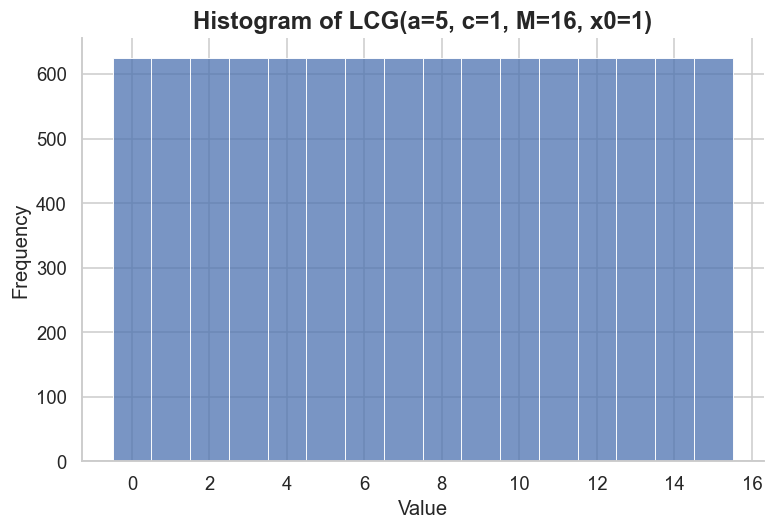

In [419]:

output = linear_congruential_generator(a, c, M, x0, size)
# plot_histogram(output, bins=16)
histogram(output, bins="auto", discrete=True, title=f"Histogram of LCG(a={a}, c={c}, M={M}, x0={x0})", xlabel="Value", ylabel="Frequency")

In [420]:
# On simple Linear congruential generator
print("Simple Linear Congruential Generator: (chi squared )")
run_and_display_chi_squared_test(output, bins=16)

# Kolmogorov-Smirnov test
##### Kolmogorov-Smirnov test #####
print("\nKolmogorov-Smirnov Test for Linear Congruential Generator:")
run_and_display_kolmogorov_smirnov_test(output)


Simple Linear Congruential Generator: (chi squared )
Chi-squared Statistic: 0.0000
P-value: 1.0000

Kolmogorov-Smirnov Test for Linear Congruential Generator:
KS Statistic: 0.0625
P-value: 0.0000



System Available Random Generator: (Kolmogorov-Smirnov test)
KS Statistic: 0.0655
P-value: 0.0000

System Available Random Generator: (chi squared )
Chi-squared Statistic: 9.2640
P-value: 0.8633


<Axes: title={'center': 'Histogram of System Generated Random Numbers'}, xlabel='Value', ylabel='Frequency'>

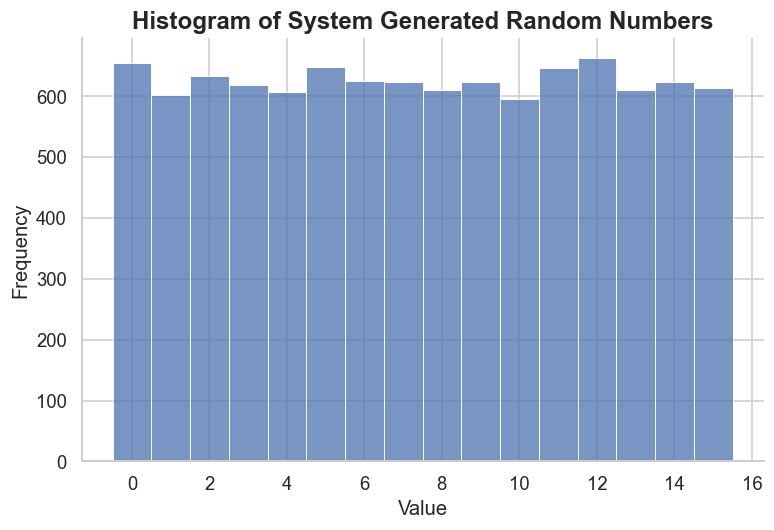

In [421]:

system_output = np.random.randint(low=0, high=16, size=size)
##### System available random generator #####
print("\nSystem Available Random Generator: (Kolmogorov-Smirnov test)")
run_and_display_kolmogorov_smirnov_test(system_output)

# On system available random generator
print("\nSystem Available Random Generator: (chi squared )")
run_and_display_chi_squared_test(system_output, bins=16)

histogram(system_output, discrete=True, title="Histogram of System Generated Random Numbers", xlabel="Value", ylabel="Frequency")

# Run above_below tests

wald-wolfowitz


In [422]:
def above_below_test(output):
    median = np.median(output)
    n1 = np.sum(output > median)
    n2 = np.sum(output < median)
    n = n1 + n2
    
    runs_above = 0
    runs_below = 0
    
    for i in range(1, len(output)):
        if output[i] > median and output[i-1] <= median:
            runs_above += 1
        elif output[i] <= median and output[i-1] > median:
            runs_below += 1
            
    print(f"Runs above median: {runs_above}, Runs below median: {runs_below}")
    T = runs_above + runs_below + 1 # Total runs (including the first run)

    # Theoretical mean and std of T under H0 (from slide)
    mu    = 2*n1*n2 / n + 1
    var   = 2*n1*n2*(2*n1*n2 - n1 - n2) / (n**2 * (n - 1))
    sigma = np.sqrt(var)
    
    # Z-score, then two-sided p-value from the Normal CDF
    Z       = (T - mu) / sigma
    p_value = 2 * (norm.sf(abs(Z)))
    
    print(f"Above median: {n1}, Below median: {n2}")
    print(f"Observed runs  T = {T}")
    print(f"Expected under H0: μ = {mu:.2f}, σ = {sigma:.4f}")
    print(f"Z = {Z:.4f},  p-value = {p_value:.4f}")
    
    return T, n1, n2, p_value
    
    
print("\nAbove-Below Test for Linear Congruential Generator:")
T, n1, n2, p_value = above_below_test(output)


Above-Below Test for Linear Congruential Generator:
Runs above median: 1875, Runs below median: 1875
Above median: 5000, Below median: 5000
Observed runs  T = 3751
Expected under H0: μ = 5001.00, σ = 49.9975
Z = -25.0013,  p-value = 0.0000


In [423]:
T, n1, n2, p_value = above_below_test(system_output)

Runs above median: 2540, Runs below median: 2540
Above median: 4986, Below median: 4391
Observed runs  T = 5081
Expected under H0: μ = 4670.62, σ = 48.2199
Z = 8.5105,  p-value = 0.0000


# Run Tests 2 : Up/Down from Knuth


In [424]:
def up_down_test(output):
    n = len(output)
    runs = []
    counter = 1
    for i in range(1, n):
        if output[i] > output[i-1]:
            counter += 1
        else:
            runs.append(counter)
            counter = 1
    runs.append(counter)  # Append the last run
    
       # Step 2: bin into R — counts for lengths 1, 2, 3, 4, 5, ≥6
    R = np.zeros(6)
    for length in runs:
        R[min(length - 1, 5)] += 1

    # A matrix and B vector from slide
    A = np.array([
        [4529.4,  9044.9, 13568,  18091,  22615,  27892 ],
        [9044.9, 18097,  27139,  36187,  45234,  55789 ],
        [13568,  27139,  40721,  54281,  67852,  83685 ],
        [18091,  36187,  54281,  72414,  90470, 111580 ],
        [22615,  45234,  67852,  90470, 113262, 139476 ],
        [27892,  55789,  83685, 111580, 139476, 172860 ],
    ])
    B = np.array([1/6, 5/24, 11/120, 19/720, 29/5040, 1/840])

    # Step 3: test statistic ~ chi2(6)
    diff    = R - n * B
    Z       = (1 / (n - 6)) * diff @ A @ diff
    p_value = chi2.sf(Z, df=6)

    print(f"Observed R  = {R.astype(int)}")
    print(f"Expected nB = {(n * B).round(1)}")
    print(f"Z = {Z:.4f},  p-value = {p_value:.4f}")

    return Z, p_value

print("\nUp-Down Test for Linear Congruential Generator:")
Z, p_value = up_down_test(output)
print("\nUp-Down Test for System Available Random Generator:")
Z, p_value = up_down_test(system_output)
            


Up-Down Test for Linear Congruential Generator:
Observed R  = [1251 1250 1251  624    0    0]
Expected nB = [1666.7 2083.3  916.7  263.9   57.5   11.9]
Z = 1116.3560,  p-value = 0.0000

Up-Down Test for System Available Random Generator:
Observed R  = [2010 2272  841  180   37    3]
Expected nB = [1666.7 2083.3  916.7  263.9   57.5   11.9]
Z = 143.6554,  p-value = 0.0000


In [425]:
def up_down_test_3(output):
    n = len(output)

    # Step 1: sign sequence (+1 = up, -1 = down, 0 = tie)
    signs = np.sign(np.diff(output))

    # Remove ties; adjust n so formula still uses original observation count
    signs = signs[signs != 0]
    n_eff = len(signs) + 1  # equals n when no ties

    # Step 2: count total runs of consecutive identical signs
    X = 1
    for i in range(1, len(signs)):
        if signs[i] != signs[i - 1]:
            X += 1

    # Step 3: Z-statistic and two-sided p-value (from slide formula)
    mu    = (2 * n_eff - 1) / 3
    sigma = np.sqrt((16 * n_eff - 29) / 90)
    Z       = (X - mu) / sigma
    p_value = 2 * norm.sf(abs(Z))

    print(f"Total runs       X = {X}")
    print(f"Expected under H0: μ = {mu:.4f},  σ = {sigma:.4f}")
    print(f"Z = {Z:.4f},  p-value = {p_value:.4f}")

    return X, Z, p_value

print("\nUp-Down Test 3 for Linear Congruential Generator:")
X, Z, p_value = up_down_test_3(output)

print("\nUp-Down Test 3 for System Available Random Generator:")
X, Z, p_value = up_down_test_3(system_output)


Up-Down Test 3 for Linear Congruential Generator:
Total runs       X = 6250
Expected under H0: μ = 6666.3333,  σ = 42.1599
Z = -9.8751,  p-value = 0.0000

Up-Down Test 3 for System Available Random Generator:
Total runs       X = 6493
Expected under H0: μ = 6252.3333,  σ = 40.8296
Z = 5.8944,  p-value = 0.0000


In [426]:
def correlation_test(U, lags=range(1, 11)):
    n = len(U)
    sigma = np.sqrt(7 / (144 * n))   # std under H0, same for all lags
    for h in lags:
        c_h = np.sum(U[:n-h] * U[h:]) / (n - h)
        Z   = (c_h - 0.25) / sigma
        p   = 2 * norm.sf(abs(Z))
        print(f"lag {h:2d}:  c_h = {c_h:.4f},  Z = {Z:+.3f},  p = {p:.4f}")

U = output / M
print("\nCorrelation Test for Linear Congruential Generator:")
correlation_test(U)

U_sys = system_output / M
print("\nCorrelation Test for System Available Random Generator:")
correlation_test(U_sys)



Correlation Test for Linear Congruential Generator:
lag  1:  c_h = 0.2422,  Z = -3.532,  p = 0.0004
lag  2:  c_h = 0.2168,  Z = -15.040,  p = 0.0000
lag  3:  c_h = 0.1954,  Z = -24.782,  p = 0.0000
lag  4:  c_h = 0.2090,  Z = -18.585,  p = 0.0000
lag  5:  c_h = 0.2266,  Z = -10.618,  p = 0.0000
lag  6:  c_h = 0.2168,  Z = -15.047,  p = 0.0000
lag  7:  c_h = 0.2110,  Z = -17.705,  p = 0.0000
lag  8:  c_h = 0.1777,  Z = -32.777,  p = 0.0000
lag  9:  c_h = 0.2109,  Z = -17.729,  p = 0.0000
lag 10:  c_h = 0.2168,  Z = -15.072,  p = 0.0000

Correlation Test for System Available Random Generator:
lag  1:  c_h = 0.2179,  Z = -14.552,  p = 0.0000
lag  2:  c_h = 0.2191,  Z = -13.993,  p = 0.0000
lag  3:  c_h = 0.2193,  Z = -13.904,  p = 0.0000
lag  4:  c_h = 0.2180,  Z = -14.502,  p = 0.0000
lag  5:  c_h = 0.2185,  Z = -14.272,  p = 0.0000
lag  6:  c_h = 0.2201,  Z = -13.567,  p = 0.0000
lag  7:  c_h = 0.2184,  Z = -14.312,  p = 0.0000
lag  8:  c_h = 0.2194,  Z = -13.881,  p = 0.0000
lag  9:  

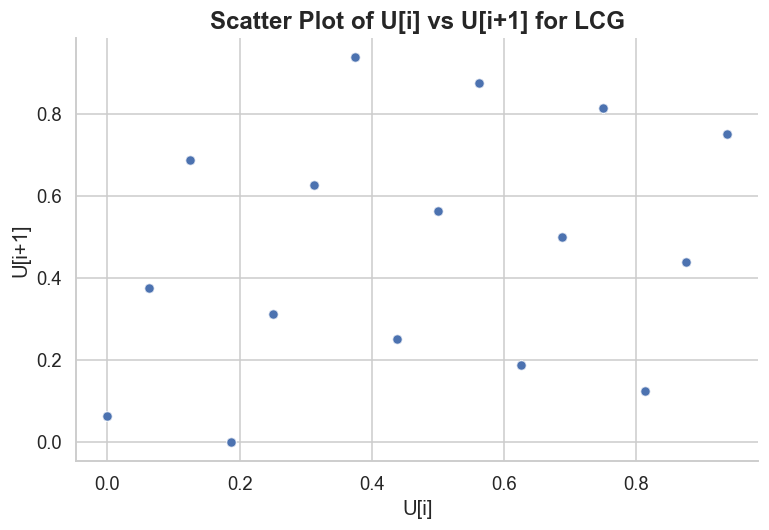

In [427]:
sns.scatterplot(x=U[:-1], y=U[1:], alpha=0.5)
plt.title("Scatter Plot of U[i] vs U[i+1] for LCG")
plt.xlabel("U[i]")
plt.ylabel("U[i+1]")
plt.show()

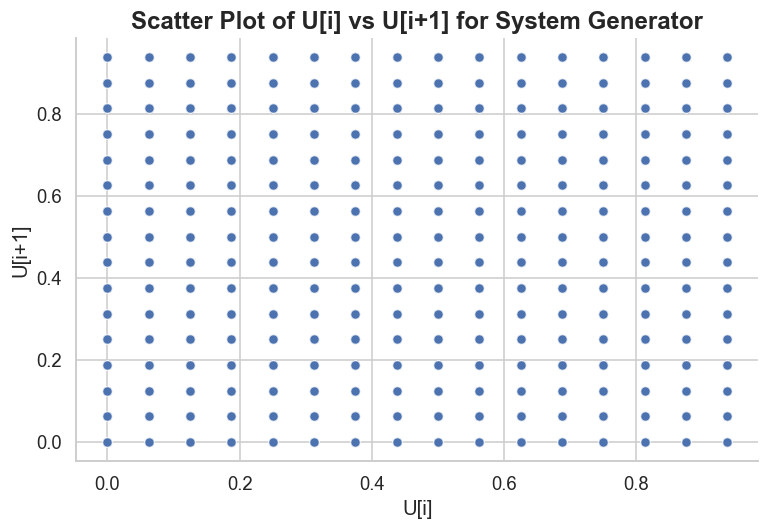

In [428]:
sns.scatterplot(x=U_sys[:-1], y=U_sys[1:], alpha=0.5)
plt.title("Scatter Plot of U[i] vs U[i+1] for System Generator")
plt.xlabel("U[i]")
plt.ylabel("U[i+1]")
plt.show()


# Decent LCG parameters

Xi+1​=(129Xi​+26461)mod65536

# Redo the tests and plots again and do some repeated sampling by the end


<Axes: title={'center': 'Histogram of LCG(a=129, c=26461, M=65536, x0=1)'}, xlabel='Value', ylabel='Frequency'>

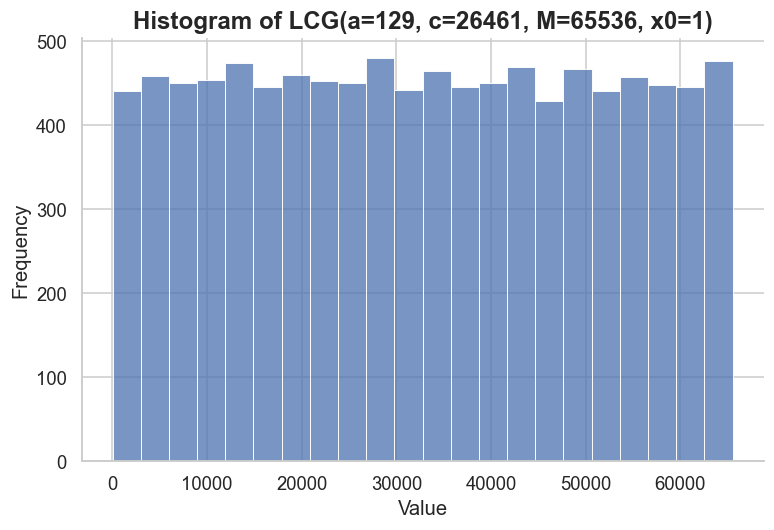

In [429]:
a = 129
c = 26461
M = 65536
N = 10000
x0 = 1

output = linear_congruential_generator(a, c, M, x0, N)
histogram(output, discrete=False, title=f"Histogram of LCG(a={a}, c={c}, M={M}, x0={x0})", xlabel="Value", ylabel="Frequency")
    

Simple Linear Congruential Generator: (chi squared )
Chi-squared Statistic: 7.9700
P-value: 0.9921

Kolmogorov-Smirnov Test for Linear Congruential Generator:
KS Statistic: 0.0031
P-value: 1.0000

Up-Down Test 3 for Linear Congruential Generator:
Total runs       X = 6646
Expected under H0: μ = 6666.3333,  σ = 42.1599
Z = -0.4823,  p-value = 0.6296

Correlation Test for Linear Congruential Generator:
lag  1:  c_h = 0.2498,  Z = -0.089,  p = 0.9293
lag  2:  c_h = 0.2493,  Z = -0.301,  p = 0.7634
lag  3:  c_h = 0.2507,  Z = +0.310,  p = 0.7563
lag  4:  c_h = 0.2500,  Z = -0.017,  p = 0.9861
lag  5:  c_h = 0.2505,  Z = +0.218,  p = 0.8277
lag  6:  c_h = 0.2504,  Z = +0.200,  p = 0.8416
lag  7:  c_h = 0.2495,  Z = -0.242,  p = 0.8091
lag  8:  c_h = 0.2501,  Z = +0.064,  p = 0.9487
lag  9:  c_h = 0.2505,  Z = +0.239,  p = 0.8111
lag 10:  c_h = 0.2504,  Z = +0.167,  p = 0.8674


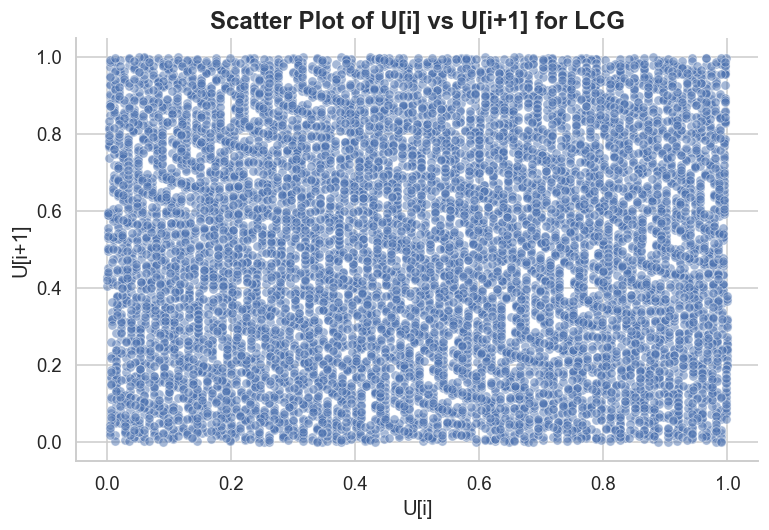

In [430]:
# Run all tests again with the new LCG parameters
print("Simple Linear Congruential Generator: (chi squared )")
run_and_display_chi_squared_test(output, bins=21)

print("\nKolmogorov-Smirnov Test for Linear Congruential Generator:")
run_and_display_kolmogorov_smirnov_test(output)

print("\nUp-Down Test 3 for Linear Congruential Generator:")
X, Z, p_value = up_down_test_3(output)

print("\nCorrelation Test for Linear Congruential Generator:")
U = output / M
correlation_test(U)
sns.scatterplot(x=U[:-1], y=U[1:], alpha=0.5)
plt.title("Scatter Plot of U[i] vs U[i+1] for LCG")
plt.xlabel("U[i]")
plt.ylabel("U[i+1]")
plt.show()




Scatter plots of U[i] vs U[i+1] for both generators


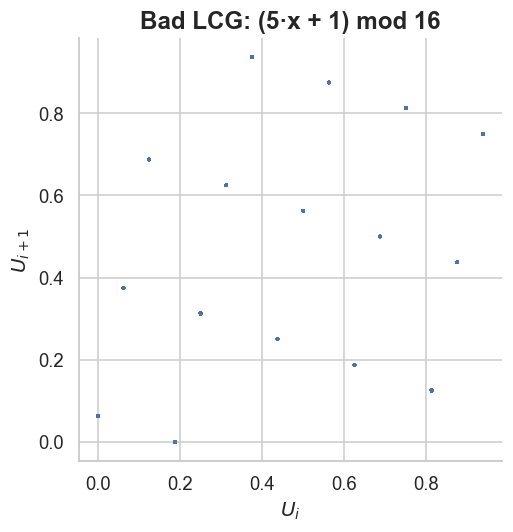

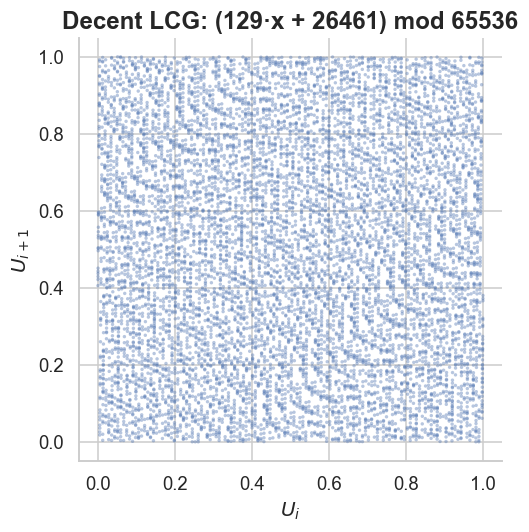

In [431]:
def scatter_plot(U, title=""):
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.scatter(U[:-1], U[1:], s=5, alpha=0.4, edgecolor="none")
    ax.set_xlabel(r"$U_i$")
    ax.set_ylabel(r"$U_{i+1}$")
    ax.set_title(title)
    ax.set_aspect("equal")
    plt.show()

# bad generator
U_bad = linear_congruential_generator(5, 1, 16, 1, 10000) / 16
scatter_plot(U_bad, "Bad LCG: (5·x + 1) mod 16")

# decent generator
U_good = linear_congruential_generator(129, 26461, 65536, 1, 10000) / 65536
scatter_plot(U_good, "Decent LCG: (129·x + 26461) mod 65536")

KS test of p-values vs Uniform(0,1): KstestResult(statistic=np.float64(0.3549252568125142), pvalue=np.float64(4.776188408169636e-23), statistic_location=np.float64(0.4849252568125142), statistic_sign=np.int8(-1))


<Axes: title={'center': 'Distribution of p-values over K samples'}, xlabel='p-value', ylabel='Count'>

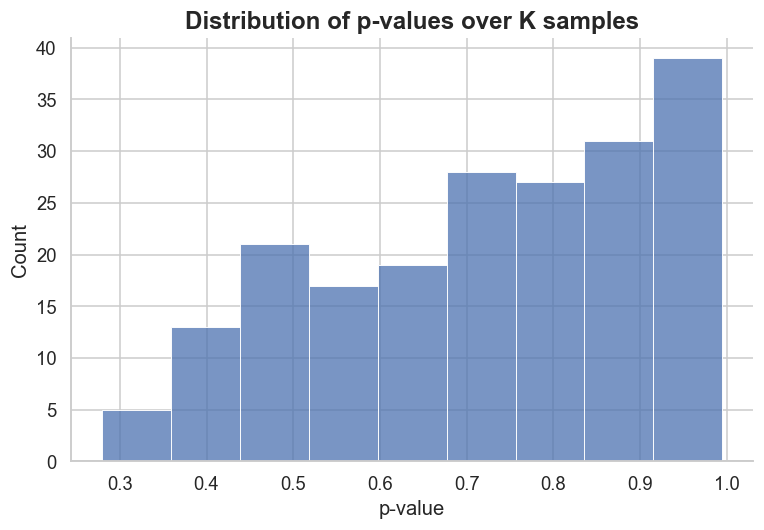

In [432]:
def collect_pvalues(a, c, M, n=10000, K=200):
    """Run the correlation test (lag 1) on K different LCG samples."""
    sigma = np.sqrt(7 / (144 * n))
    pvals = []
    for k in range(K):
        x0 = 1 + k                      # different seed/phase each time
        U  = linear_congruential_generator(a, c, M, x0, n) / M
        c1 = np.sum(U[:-1] * U[1:]) / (n - 1)
        Z  = (c1 - 0.25) / sigma
        pvals.append(2 * norm.sf(abs(Z)))
    return np.array(pvals)

pvals = collect_pvalues(129, 26461, 65536)
# Under H0 these should be ~Uniform(0,1):
print("KS test of p-values vs Uniform(0,1):", kstest(pvals, "uniform"))
histogram(pvals, title="Distribution of p-values over K samples",
          xlabel="p-value", ylabel="Count")

KS test of system p-values vs Uniform(0,1): KstestResult(statistic=np.float64(0.18058261479232335), pvalue=np.float64(3.531162520696991e-06), statistic_location=np.float64(0.24941738520767665), statistic_sign=np.int8(1))


<Axes: title={'center': 'System generator: p-values over K samples'}, xlabel='p-value', ylabel='Count'>

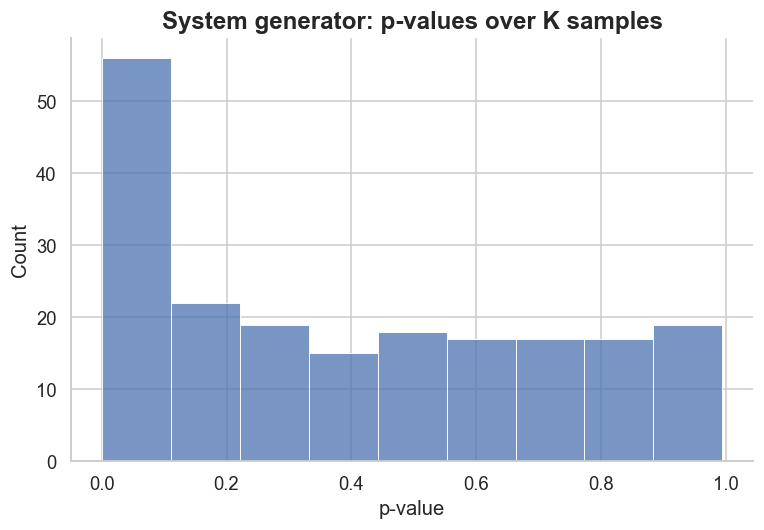

In [433]:
def collect_pvalues_system(n=10000, K=200, seed=42):
    rng   = np.random.default_rng(seed)
    sigma = np.sqrt(7 / (144 * n))
    pvals = []
    for k in range(K):
        U  = rng.random(n)              # fresh, INDEPENDENT continuous uniforms
        c1 = np.sum(U[:-1] * U[1:]) / (n - 1)
        Z  = (c1 - 0.25) / sigma
        pvals.append(2 * norm.sf(abs(Z)))
    return np.array(pvals)

p_sys = collect_pvalues_system()
print("KS test of system p-values vs Uniform(0,1):", kstest(p_sys, "uniform"))
histogram(p_sys, title="System generator: p-values over K samples",
          xlabel="p-value", ylabel="Count")